In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_theme(style="whitegrid")

Libraries imported successfully!


In [4]:
import pandas as pd

file_path = "D:/Documents/Projects/Intern/Datasets_Provided/4) house Prediction Data Set.csv"

column_names = [
    "CRIM", "ZN", "INDUS", "CHAS", "NOX", "RM", "AGE",
    "DIS", "RAD", "TAX", "PTRATIO", "B", "LSTAT", "MEDV"
]

df = pd.read_csv(
    file_path,
    sep=r"\s+",
    header=None,
    names=column_names
)

df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
X = df.drop(columns="MEDV")
y = df["MEDV"]

In [6]:
print(X.shape)
print(y.shape)

(506, 13)
(506,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (404, 13)
X_test: (102, 13)
y_train: (404,)
y_test: (102,)


In [9]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [10]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['CRIM','ZN','INDUS',...,'PTRATIO','B','LSTAT']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [11]:
predictions = model.predict(X_test)

In [12]:
predictions[:5]

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992])

In [13]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": predictions
})

comparison.head(10)

,Actual Price,Predicted Price
0,23.6,28.996724
1,32.4,36.025565
2,13.6,14.816944
3,22.8,25.031979
4,16.1,18.769880
5,20.0,23.254429
6,17.8,17.662538
7,14.0,14.341190
8,19.6,23.013207
9,16.8,20.632456


In [14]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [15]:
mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 3.1890919658878416
RMSE: 4.928602182665339
R² Score: 0.6687594935356317


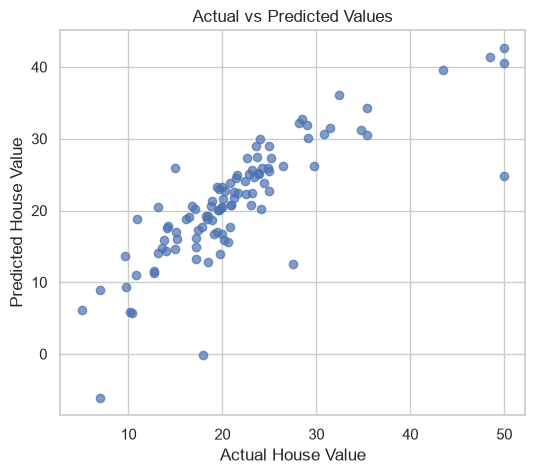

In [16]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.show()

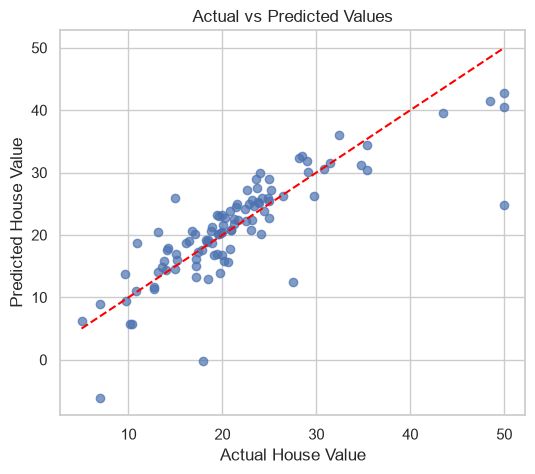

In [17]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    predictions,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted Values")

plt.show()

In [18]:
from sklearn.tree import DecisionTreeRegressor

In [19]:
tree_model = DecisionTreeRegressor(
    random_state=42
)

In [20]:
tree_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [22]:
tree_predictions = tree_model.predict(X_test)

In [23]:
tree_mae = mean_absolute_error(
    y_test,
    tree_predictions
)

tree_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        tree_predictions
    )
)

tree_r2 = r2_score(
    y_test,
    tree_predictions
)

print("Decision Tree MAE:", tree_mae)
print("Decision Tree RMSE:", tree_rmse)
print("Decision Tree R²:", tree_r2)

Decision Tree MAE: 2.7245098039215683
Decision Tree RMSE: 4.220851600719234
Decision Tree R²: 0.7570616506127126


In [24]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

forest_predictions = forest_model.predict(X_test)

In [25]:
n_estimators=100

In [26]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        forest_predictions
    )
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest MAE:", forest_mae)
print("Random Forest RMSE:", forest_rmse)
print("Random Forest R²:", forest_r2)

Random Forest MAE: 2.0367352941176473
Random Forest RMSE: 2.807172478407661
Random Forest R²: 0.8925431501835708


In [27]:
from sklearn.tree import export_text

rules = export_text(
    tree_model,
    feature_names=list(X.columns),
    max_depth=3
)

print(rules)

|--- RM <= 6.94
|   |--- LSTAT <= 14.40
|   |   |--- DIS <= 1.38
|   |   |   |--- CRIM <= 10.11
|   |   |   |   |--- value: [50.00]
|   |   |   |--- CRIM >  10.11
|   |   |   |   |--- value: [27.90]
|   |   |--- DIS >  1.38
|   |   |   |--- RM <= 6.54
|   |   |   |   |--- truncated branch of depth 16
|   |   |   |--- RM >  6.54
|   |   |   |   |--- truncated branch of depth 9
|   |--- LSTAT >  14.40
|   |   |--- CRIM <= 6.93
|   |   |   |--- AGE <= 73.30
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- AGE >  73.30
|   |   |   |   |--- truncated branch of depth 13
|   |   |--- CRIM >  6.93
|   |   |   |--- LSTAT <= 19.85
|   |   |   |   |--- truncated branch of depth 11
|   |   |   |--- LSTAT >  19.85
|   |   |   |   |--- truncated branch of depth 10
|--- RM >  6.94
|   |--- RM <= 7.44
|   |   |--- LSTAT <= 15.76
|   |   |   |--- DIS <= 1.89
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- DIS >  1.89
|   |   |   |   |--- truncated branch of depth 11
|

In [28]:
from sklearn.ensemble import RandomForestRegressor

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [29]:
forest_mae = mean_absolute_error(
    y_test,
    forest_predictions
)

forest_rmse = np.sqrt(
    mean_squared_error(y_test, forest_predictions)
)

forest_r2 = r2_score(
    y_test,
    forest_predictions
)

print("Random Forest MAE:", forest_mae)
print("Random Forest RMSE:", forest_rmse)
print("Random Forest R²:", forest_r2)

Random Forest MAE: 2.0367352941176473
Random Forest RMSE: 2.807172478407661
Random Forest R²: 0.8925431501835708


In [30]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    
    "MAE": [
        mae,
        tree_mae,
        forest_mae
    ],
    
    "RMSE": [
        rmse,
        tree_rmse,
        forest_rmse
    ],
    
    "R2 Score": [
        r2,
        tree_r2,
        forest_r2
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,3.189092,4.928602,0.668759
1,Decision Tree,2.724510,4.220852,0.757062
2,Random Forest,2.036735,2.807172,0.892543


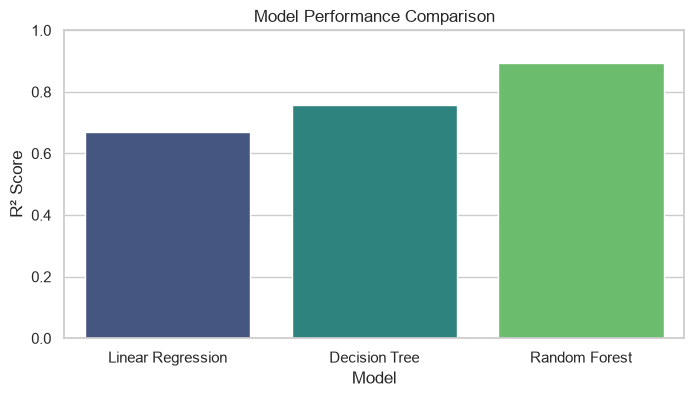

In [31]:
plt.figure(figsize=(8, 4))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score",
    hue="Model",
    palette="viridis",
    legend=False
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)

plt.show()

In [33]:
forest_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,RM,0.504274
12,LSTAT,0.309532
7,DIS,0.059881
0,CRIM,0.037635
10,PTRATIO,0.016242
9,TAX,0.016142
4,NOX,0.014987
6,AGE,0.013845
11,B,0.012754
2,INDUS,0.007742


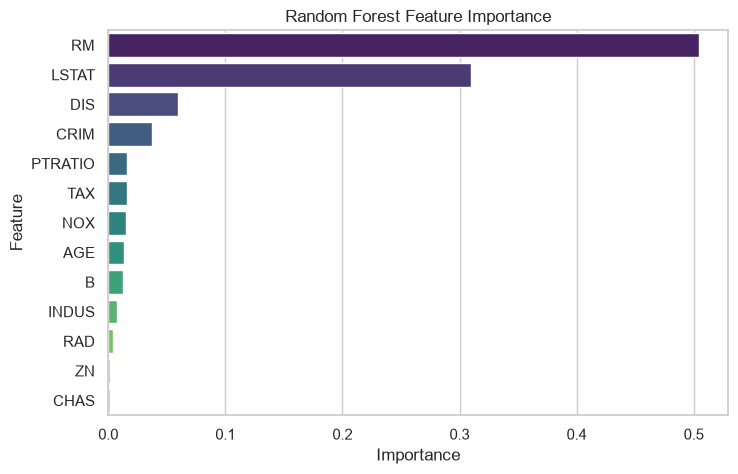

In [35]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [36]:
from sklearn.dummy import DummyRegressor

dummy_model = DummyRegressor(strategy="mean")

dummy_model.fit(X_train, y_train)

dummy_predictions = dummy_model.predict(X_test)

In [37]:
strategy="mean"

In [38]:
dummy_predictions[:10]

array([22.79653465, 22.79653465, 22.79653465, 22.79653465, 22.79653465,
       22.79653465, 22.79653465, 22.79653465, 22.79653465, 22.79653465])

In [39]:
dummy_mae = mean_absolute_error(
    y_test,
    dummy_predictions
)

dummy_rmse = np.sqrt(
    mean_squared_error(y_test, dummy_predictions)
)

dummy_r2 = r2_score(
    y_test,
    dummy_predictions
)

print("Dummy MAE:", dummy_mae)
print("Dummy RMSE:", dummy_rmse)
print("Dummy R²:", dummy_r2)

Dummy MAE: 6.255843525529023
Dummy RMSE: 8.662876564628665
Dummy R²: -0.023340500652033302


In [40]:
results = pd.DataFrame({
    "Model": [
        "Dummy Baseline",
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE": [
        dummy_mae,
        mae,
        tree_mae,
        forest_mae
    ],

    "RMSE": [
        dummy_rmse,
        rmse,
        tree_rmse,
        forest_rmse
    ],

    "R2 Score": [
        dummy_r2,
        r2,
        tree_r2,
        forest_r2
    ]
})

results = results.sort_values(
    by="R2 Score",
    ascending=False
)

results

,Model,MAE,RMSE,R2 Score
3,Random Forest,2.036735,2.807172,0.892543
2,Decision Tree,2.724510,4.220852,0.757062
1,Linear Regression,3.189092,4.928602,0.668759
0,Dummy Baseline,6.255844,8.662877,-0.023341


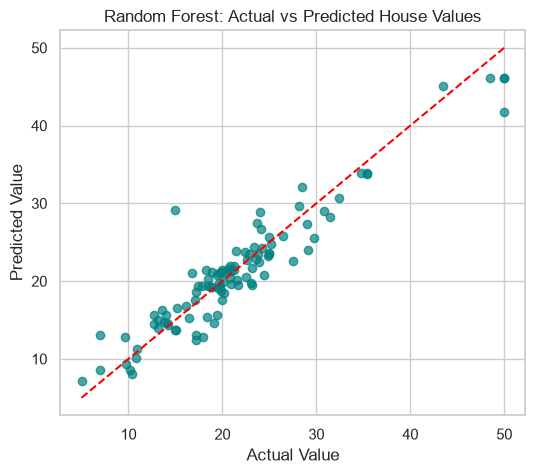

In [41]:
plt.figure(figsize=(6, 5))

plt.scatter(
    y_test,
    forest_predictions,
    alpha=0.7,
    color="teal"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.title("Random Forest: Actual vs Predicted House Values")
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")

plt.show()

In [ ]:
## Conclusion

#In this task, multiple regression models were trained to predict median house values.

#The models were evaluated using MAE, RMSE, and R² score. Linear Regression provided a useful baseline ML model, while Decision Tree Regression captured nonlinear relationships more effectively. Random Forest Regression achieved the best overall performance among the tested models.

#Therefore, Random Forest was selected as the best-performing model for this dataset.